In [ ]:
import pandas as pd
import numpy as np

# visualization

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import matplotlib.dates as mdates

# scaler

from sklearn.preprocessing import RobustScaler

# model

from sklearn.linear_model import LinearRegression

# metrics

from sklearn.metrics import mean_squared_error,root_mean_squared_error, mean_absolute_percentage_error, r2_score


In [ ]:
ffill_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/ffill_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')

bfill_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/bfill_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')

interpolation_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/interpolation_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')

# Train-Validation-Test Splits

In [ ]:
for_validation = 160
for_test = 160


ffill_train = ffill_df.iloc[:-for_validation-for_test]
ffill_val = ffill_df.iloc[-for_validation-for_test:-for_test]
ffill_test = ffill_df.iloc[-for_test:]

bfill_train = bfill_df.iloc[:-for_validation-for_test]
bfill_val = bfill_df.iloc[-for_validation-for_test:-for_test]
bfill_test = bfill_df.iloc[-for_test:]

interpolation_train = interpolation_df.iloc[:-for_validation-for_test]
interpolation_val = interpolation_df.iloc[-for_validation-for_test:-for_test]
interpolation_test = interpolation_df.iloc[-for_test:]

# Train, Validation, and Test Splits

print('Training, Validation, and Test for ffill dataset')

ffill_train_shape = ffill_train.shape
ffill_val_shape = ffill_val.shape
ffill_test_shape = ffill_test.shape

print(f'ffill_df_for_modeling_train shape: {ffill_train_shape}')
print(f'ffill_df_for_modeling_val shape: {ffill_val_shape}')
print(f'ffill_df_for_modeling_test shape: {ffill_test_shape}')

print("="*50)

print('Training, Validation, and Test for bfill dataset')

bfill_train_shape = bfill_train.shape
bfill_val_shape = bfill_val.shape
bfill_test_shape = bfill_test.shape

print(f'bfill_df_for_modeling_train shape: {bfill_train_shape}')
print(f'bfill_df_for_modeling_val shape: {bfill_val_shape}')
print(f'bfill_df_for_modeling_test shape: {bfill_test_shape}')

print("="*50)

print('Training, Validation, and Test for  interpolation dataset')

interpolation_train_shape = interpolation_train.shape
interpolation_val_shape = interpolation_val.shape
interpolation_test_shape = interpolation_test.shape

print(f'interpolation_df_for_modeling_train shape: {interpolation_train_shape}')
print(f'interpolation_f_for_modeling_val shape: {interpolation_val_shape}')
print(f'interpolation_df_for_modeling_test shape: {interpolation_test_shape}')


Training, Validation, and Test for ffill dataset
ffill_df_for_modeling_train shape: (858, 36)
ffill_df_for_modeling_val shape: (160, 36)
ffill_df_for_modeling_test shape: (160, 36)
Training, Validation, and Test for bfill dataset
bfill_df_for_modeling_train shape: (855, 34)
bfill_df_for_modeling_val shape: (160, 34)
bfill_df_for_modeling_test shape: (160, 34)
Training, Validation, and Test for  interpolation dataset
interpolation_df_for_modeling_train shape: (858, 34)
interpolation_f_for_modeling_val shape: (160, 34)
interpolation_df_for_modeling_test shape: (160, 34)


## Inputs and Target

In [ ]:
target_col = 'IN, COD'

ffill_train_input = ffill_train.drop(target_col, axis=1)
ffill_val_input = ffill_val.drop(target_col, axis=1)
ffill_test_input = ffill_test.drop(target_col, axis=1)

ffill_train_target = ffill_train[target_col]
ffill_val_target = ffill_val[target_col]
ffill_test_target = ffill_test[target_col]


bfill_train_input = bfill_train.drop(target_col, axis=1)
bfill_val_input = bfill_val.drop(target_col, axis=1)
bfill_test_input = bfill_test.drop(target_col, axis=1)

bfill_train_target = bfill_train[target_col]
bfill_val_target = bfill_val[target_col]
bfill_test_target = bfill_test[target_col]


interpolation_train_input = interpolation_train.drop(target_col, axis=1)
interpolation_val_input = interpolation_val.drop(target_col, axis=1)
interpolation_test_input = interpolation_test.drop(target_col, axis=1)

interpolation_train_target = interpolation_train[target_col]
interpolation_val_target = interpolation_val[target_col]
interpolation_test_target = interpolation_test[target_col]

## Scaling

- Because most features exhibit some outliers and extreme volatility, a RobustScaler was used to safely preserve operational patterns.

In [ ]:
scaler = RobustScaler()

# FFILL

flinear_train_input = scaler.fit_transform(ffill_train_input)
flinear_val_input = scaler.transform(ffill_val_input)
flinear_test_input = scaler.transform(ffill_test_input)

flinear_train_target = scaler.fit_transform(ffill_train_target.values.reshape(-1, 1))
flinear_val_target = scaler.transform(ffill_val_target.values.reshape(-1, 1))
flinear_test_target = scaler.transform(ffill_test_target.values.reshape(-1, 1))

# BFILL

blinear_train_input = scaler.fit_transform(bfill_train_input)
blinear_val_input = scaler.transform(bfill_val_input)
blinear_test_input = scaler.transform(bfill_test_input)

blinear_train_target = scaler.fit_transform(bfill_train_target.values.reshape(-1, 1))
blinear_val_target = scaler.transform(bfill_val_target.values.reshape(-1, 1))
blinear_test_target = scaler.transform(bfill_test_target.values.reshape(-1, 1))

# Interpolation

ilinear_train_input = scaler.fit_transform(interpolation_train_input)
ilinear_val_input = scaler.transform(interpolation_val_input)
ilinear_test_input = scaler.transform(interpolation_test_input)

ilinear_train_target = scaler.fit_transform(interpolation_train_target.values.reshape(-1, 1))
ilinear_val_target = scaler.transform(interpolation_val_target.values.reshape(-1, 1))
ilinear_test_target = scaler.transform(interpolation_test_target.values.reshape(-1, 1))

# Linear Regression Model

In [ ]:
model_linear_ffill = LinearRegression(fit_intercept = True)
model_linear_bfill = LinearRegression(fit_intercept = True)
model_linear_interpolation = LinearRegression(fit_intercept = True)

model_linear_ffill.fit(flinear_train_input, flinear_train_target)
model_linear_bfill.fit(blinear_train_input, blinear_train_target)
model_linear_interpolation.fit(ilinear_train_input, ilinear_train_target)

LinearRegression()

## Linear Regression Prediction

In [ ]:
ffill_val_pred_linear = model_linear_ffill.predict(flinear_val_input)
bfill_val_pred_linear = model_linear_bfill.predict(blinear_val_input)
interpolation_val_pred_linear = model_linear_interpolation.predict(ilinear_val_input)

## Inverse Transform

In [ ]:
# Inverse Transform

ffill_val_pred_linear = scaler.inverse_transform(ffill_val_pred_linear)
bfill_val_pred_linear = scaler.inverse_transform(bfill_val_pred_linear)
interpolation_val_pred_linear = scaler.inverse_transform(interpolation_val_pred_linear)

In [ ]:
def plot_predictions(y_train,y_val, y_prediction, data_set):

  # Convert y_prediction to a 1-dimensional array before creating a Series
  y_prediction_series = pd.Series(y_prediction.ravel(), index=y_val.index)

  plt.figure(figsize=(12,6))
  plt.plot(y_train.index, y_train.values, label='Train')
  plt.plot(y_val.index, y_val.values, label='Validation')
  plt.plot(y_prediction_series.index, y_prediction_series.values, label='Prediction')
  plt.title(f'Predictions for {data_set}')
  plt.legend()
  plt.xticks(rotation=45)
  plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
  plt.tight_layout()
  plt.show()

  rmse = np.sqrt(mean_squared_error(y_val, y_prediction.ravel()))
  print(f'RMSE: {rmse}')
  mape = mean_absolute_percentage_error(y_val, y_prediction.ravel())
  print(f'MAPE: {mape}')
  r2 = r2_score(y_val, y_prediction.ravel())
  print(f'R2: {r2}')

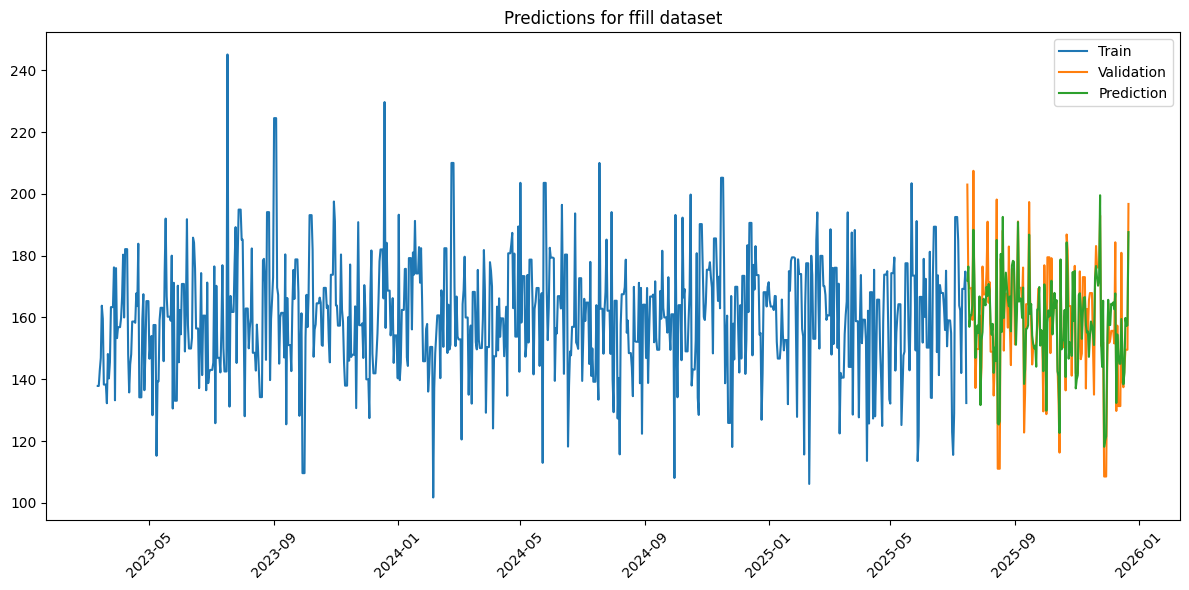

RMSE: 9.564474245283607
MAPE: 0.049809109253041585
R2: 0.7496777654920662


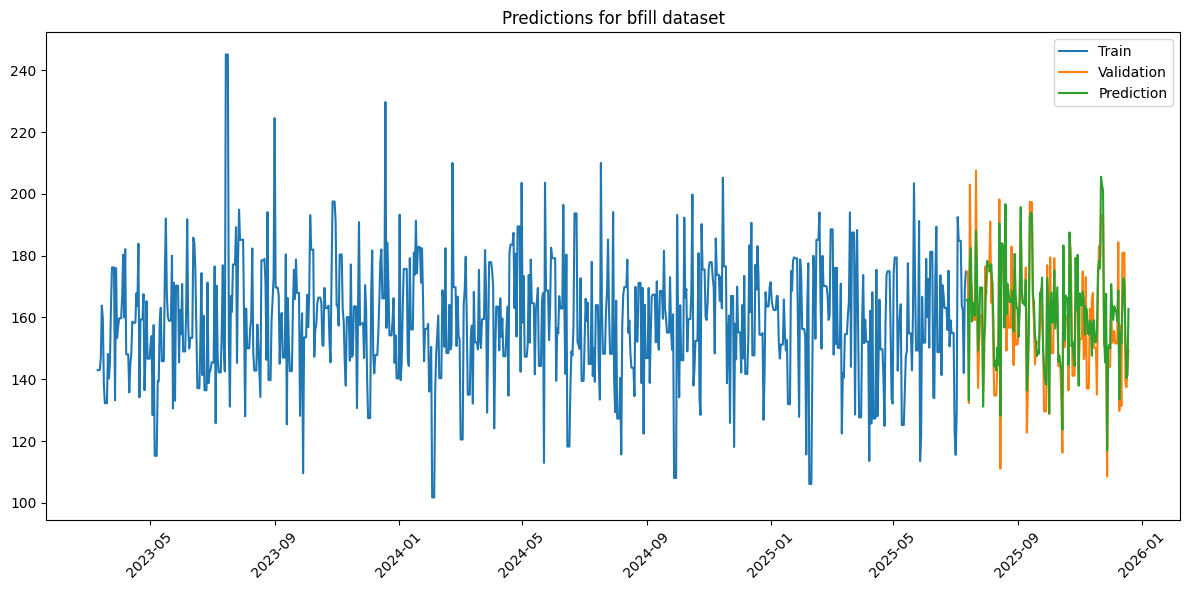

RMSE: 9.724289109689977
MAPE: 0.05188983868194878
R2: 0.7290144363300919


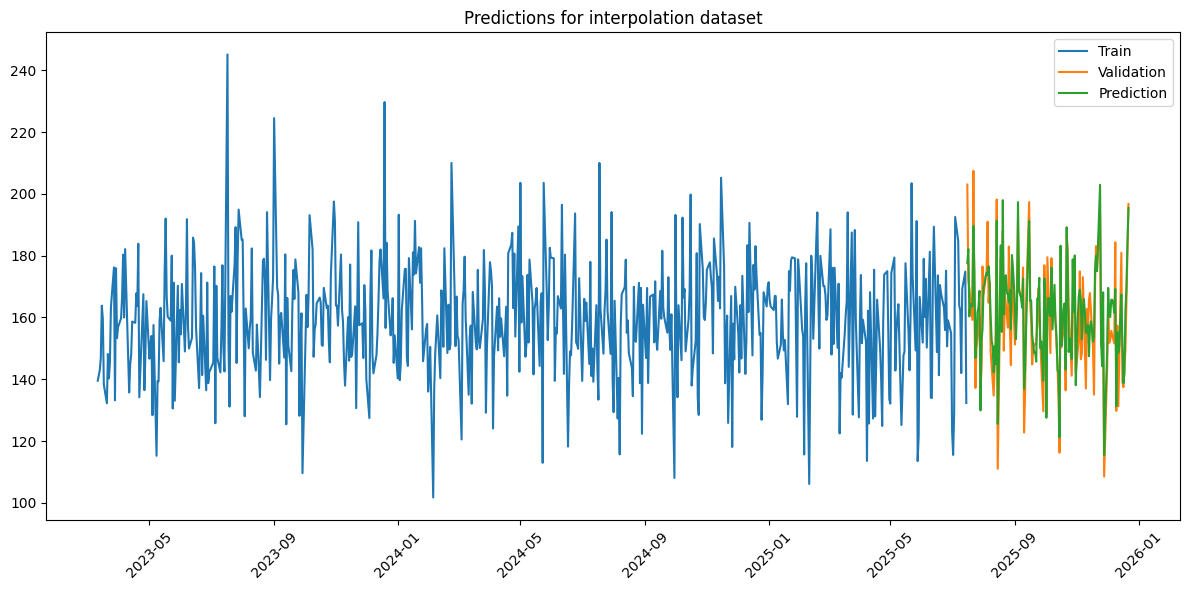

RMSE: 8.825337045577974
MAPE: 0.045967143756060536
R2: 0.7555322909269256


In [ ]:
plot_predictions(ffill_train_target, ffill_val_target, ffill_val_pred_linear, 'ffill dataset')
plot_predictions(bfill_train_target, bfill_val_target, bfill_val_pred_linear, 'bfill dataset')
plot_predictions(interpolation_train_target, interpolation_val_target, interpolation_val_pred_linear, 'interpolation dataset')



---
Because Linear Regression assumes a straight-line relationship between data points, using linear interpolation for missing value **imputation method yielded the lowest error**

---



## Residual Analysis and R2 score

In [ ]:
def residual_plot(df_val, val_predictions):

  residuals = df_val - val_predictions.ravel()

  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=val_predictions.ravel(), y=residuals, alpha=0.6)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.xlabel('Predicted Values')
  plt.ylabel('Residuals')
  plt.title('Residual Plot')
  plt.grid(True)
  plt.tight_layout()
  plt.show()


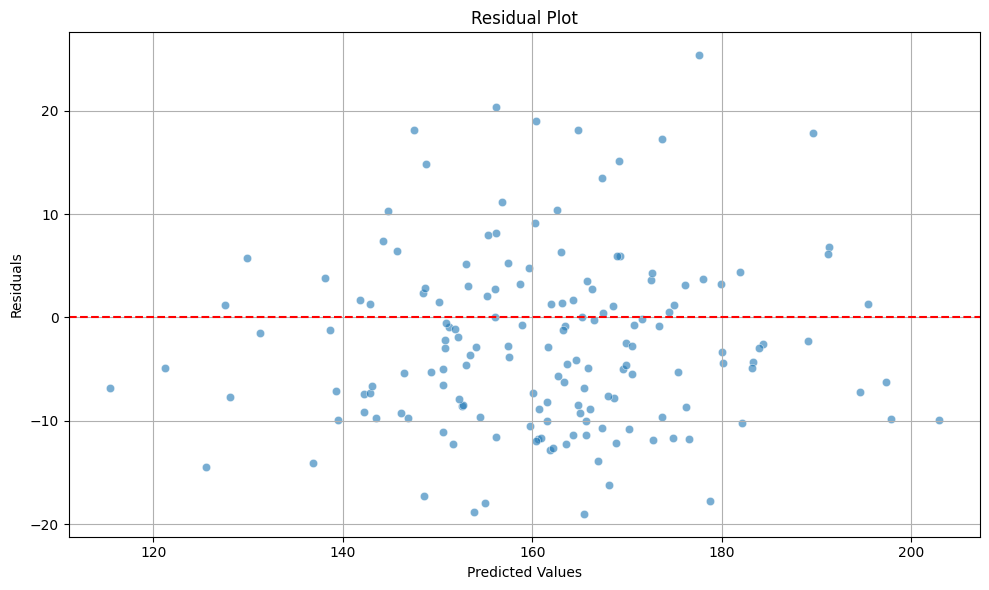

In [ ]:
residual_plot(interpolation_val_target, interpolation_val_pred_linear)

In [ ]:
def r2_score_plot(y_val, y_prediction, model):
    r2 = r2_score(y_val, y_prediction)
    y_val, y_prediction = np.asarray(y_val), np.asarray(y_prediction)

    min_val = min(y_val.min(), y_prediction.min())
    max_val = max(y_val.max(), y_prediction.max())

    plt.figure(figsize=(8, 6))
    plt.scatter(y_val, y_prediction, alpha=0.7, edgecolor='black', label='Predictions')
    plt.plot([min_val, max_val], [min_val, max_val],
             '--', color='red', linewidth=2, label='Perfect Prediction')

    plt.xlabel('Actual COD (mg/L)')
    plt.ylabel('Predicted COD (mg/L)')
    plt.title(f'{model} Model: Actual vs. Predicted COD', fontweight='bold')

    plt.text(
        0.05, 0.95, f'$R^2$ = {r2:.3f}',
        transform=plt.gca().transAxes,
        fontsize=11, fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='none',
                  edgecolor='black', linewidth=1)
    )

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

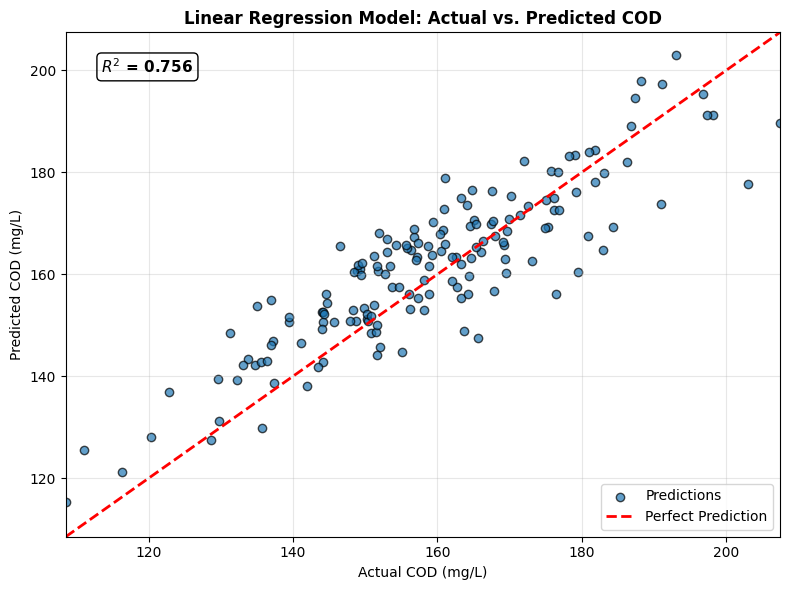

In [ ]:
r2_score_plot(interpolation_val_target, interpolation_val_pred_linear, 'Linear Regression')

# Model Discussion (Linear Regression)

- The interpolation imputation had the lowest error.

- The **Linear Regression model** yielded an **RMSE of 8.825** and an **R2 score of 0.756**. This performance is directly attributed to the use of linear interpolation during data preprocessing, which inherently biased the model's outputs toward linear relationships.

- A few isolated outliers at the extreme ends suggest the model struggles slightly with highly volatile environmental peaks.